In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, r2_score

In [42]:
df = pd.read_csv("service-requests-real-a03a7a.csv")

df.head()

,sr_number,sr_type,sr_short_code,created_department,owner_department,status,origin,created_date,last_modified_date,street_address,...,police_beat,precinct,created_hour,created_day_of_week,created_month,x_coordinate,y_coordinate,latitude,longitude,location
0,SR26-00477259,Water On Street Complaint,AAE,311 City Services,DWM - Department of Water Management,Open,Phone Call,2026-03-17T11:14:46.000,2026-03-17T11:14:50.000,5515 W POTOMAC AVE,...,2532.0,5.0,11,3,3,1.139077e+06,1.908023e+06,41.903739,-87.764589,"{""latitude"":""41.903739000941"",""longitude"":""-87..."
1,SR26-00477258,311 INFORMATION ONLY CALL,311IOC,311 City Services,311 City Services,Completed,Phone Call,2026-03-17T11:14:40.000,2026-03-17T11:14:41.000,2111 W Lexington ST,...,NaN,NaN,11,3,3,NaN,NaN,NaN,NaN,NaN
2,SR26-00477257,Street Light Pole Damage Complaint,SFK,311 City Services,CDOT - Department of Transportation,Open,Phone Call,2026-03-17T11:14:34.000,2026-03-17T11:14:41.000,10226 S HALSTED ST,...,2232.0,45.0,11,3,3,1.172682e+06,1.836882e+06,41.707845,-87.643247,"{""latitude"":""41.70784500094"",""longitude"":""-87...."
3,SR26-00477255,311 INFORMATION ONLY CALL,311IOC,311 City Services,311 City Services,Completed,Phone Call,2026-03-17T11:14:21.000,2026-03-17T11:14:22.000,2111 W Lexington ST,...,NaN,NaN,11,3,3,NaN,NaN,NaN,NaN,NaN
4,SR26-00477253,311 INFORMATION ONLY CALL,311IOC,311 City Services,311 City Services,Completed,Phone Call,2026-03-17T11:13:59.000,2026-03-17T11:13:59.000,2111 W Lexington ST,...,NaN,NaN,11,3,3,NaN,NaN,NaN,NaN,NaN


In [43]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.info()

Number of rows: 2000
Number of columns: 35
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sr_number            2000 non-null   object 
 1   sr_type              2000 non-null   object 
 2   sr_short_code        2000 non-null   object 
 3   created_department   1342 non-null   object 
 4   owner_department     2000 non-null   object 
 5   status               2000 non-null   object 
 6   origin               2000 non-null   object 
 7   created_date         2000 non-null   object 
 8   last_modified_date   2000 non-null   object 
 9   street_address       1999 non-null   object 
 10  city                 1806 non-null   object 
 11  state                1806 non-null   object 
 12  zip_code             1721 non-null   float64
 13  street_number        1999 non-null   float64
 14  street_direction     1998 non-null   object 


In [44]:
df.isnull().sum()

sr_number                 0
sr_type                   0
sr_short_code             0
created_department      658
owner_department          0
status                    0
origin                    0
created_date              0
last_modified_date        0
street_address            1
city                    194
state                   194
zip_code                279
street_number             1
street_direction          2
street_name               1
street_type              33
duplicate              1920
legacy_record          2000
community_area          110
ward                    109
electrical_district     292
electricity_grid        293
police_sector           110
police_district         110
police_beat             110
precinct                112
created_hour              0
created_day_of_week       0
created_month             0
x_coordinate            106
y_coordinate            106
latitude                106
longitude               106
location                106
dtype: int64

In [45]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [46]:
df["created_date"] = pd.to_datetime(df["created_date"])

df.head()

,sr_number,sr_type,sr_short_code,created_department,owner_department,status,origin,created_date,last_modified_date,street_address,...,police_beat,precinct,created_hour,created_day_of_week,created_month,x_coordinate,y_coordinate,latitude,longitude,location
0,SR26-00477259,Water On Street Complaint,AAE,311 City Services,DWM - Department of Water Management,Open,Phone Call,2026-03-17 11:14:46,2026-03-17T11:14:50.000,5515 W POTOMAC AVE,...,2532.0,5.0,11,3,3,1.139077e+06,1.908023e+06,41.903739,-87.764589,"{""latitude"":""41.903739000941"",""longitude"":""-87..."
1,SR26-00477258,311 INFORMATION ONLY CALL,311IOC,311 City Services,311 City Services,Completed,Phone Call,2026-03-17 11:14:40,2026-03-17T11:14:41.000,2111 W Lexington ST,...,NaN,NaN,11,3,3,NaN,NaN,NaN,NaN,NaN
2,SR26-00477257,Street Light Pole Damage Complaint,SFK,311 City Services,CDOT - Department of Transportation,Open,Phone Call,2026-03-17 11:14:34,2026-03-17T11:14:41.000,10226 S HALSTED ST,...,2232.0,45.0,11,3,3,1.172682e+06,1.836882e+06,41.707845,-87.643247,"{""latitude"":""41.70784500094"",""longitude"":""-87...."
3,SR26-00477255,311 INFORMATION ONLY CALL,311IOC,311 City Services,311 City Services,Completed,Phone Call,2026-03-17 11:14:21,2026-03-17T11:14:22.000,2111 W Lexington ST,...,NaN,NaN,11,3,3,NaN,NaN,NaN,NaN,NaN
4,SR26-00477253,311 INFORMATION ONLY CALL,311IOC,311 City Services,311 City Services,Completed,Phone Call,2026-03-17 11:13:59,2026-03-17T11:13:59.000,2111 W Lexington ST,...,NaN,NaN,11,3,3,NaN,NaN,NaN,NaN,NaN


In [47]:
print("Starting date:", df["created_date"].min())
print("Ending date:", df["created_date"].max())

print("\nAvailable dates:")
print(df["created_date"].dt.date.unique())

Starting date: 2026-03-16 21:45:13
Ending date: 2026-03-17 11:14:46

Available dates:
[datetime.date(2026, 3, 17) datetime.date(2026, 3, 16)]


In [48]:
df["hour"] = df["created_date"].dt.hour

df[["created_date", "hour"]].head()

,created_date,hour
0,2026-03-17 11:14:46,11
1,2026-03-17 11:14:40,11
2,2026-03-17 11:14:34,11
3,2026-03-17 11:14:21,11
4,2026-03-17 11:13:59,11


In [49]:
hourly_demand = df.groupby("hour").size().reset_index(name="demand")

hourly_demand = hourly_demand.sort_values("hour")

hourly_demand

,hour,demand
0,0,50
1,1,45
2,2,32
3,3,21
4,4,52
5,5,51
6,6,148
7,7,216
8,8,326
9,9,365


In [50]:
print("Number of hourly observations:", len(hourly_demand))

print("\nHourly demand:")
print(hourly_demand)

Number of hourly observations: 15

Hourly demand:
    hour  demand
0      0      50
1      1      45
2      2      32
3      3      21
4      4      52
5      5      51
6      6     148
7      7     216
8      8     326
9      9     365
10    10     399
11    11      70
12    21      47
13    22     115
14    23      63


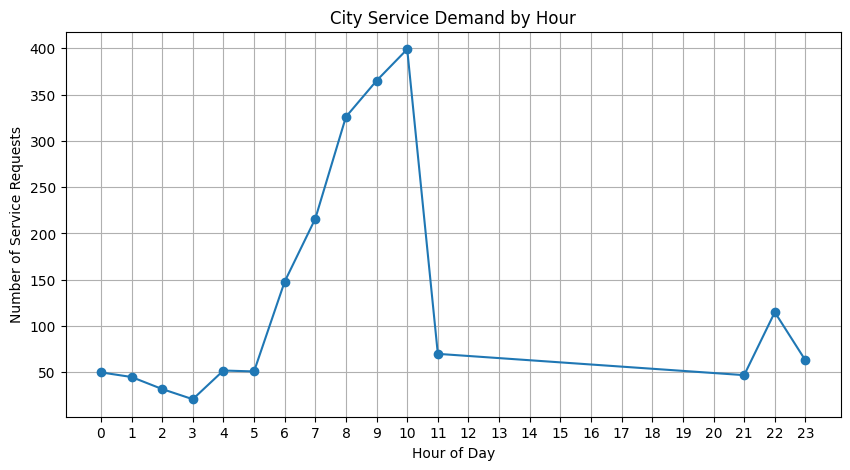

In [51]:
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_demand["hour"],
    hourly_demand["demand"],
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Number of Service Requests")
plt.title("City Service Demand by Hour")

plt.xticks(range(24))

plt.grid(True)

plt.show()

In [52]:
X = hourly_demand[["hour"]]

y = hourly_demand["demand"]

print("Input X:")
print(X.head())

print("\nTarget y:")
print(y.head())

Input X:
   hour
0     0
1     1
2     2
3     3
4     4

Target y:
0    50
1    45
2    32
3    21
4    52
Name: demand, dtype: int64


In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 12
Testing data: 3


In [54]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_prediction = linear_model.predict(X_test)

linear_mse = mean_squared_error(
    y_test,
    linear_prediction
)

linear_rmse = np.sqrt(linear_mse)

linear_r2 = r2_score(
    y_test,
    linear_prediction
)

print("Linear Regression")
print("MSE:", linear_mse)
print("RMSE:", linear_rmse)
print("R2 Score:", linear_r2)

Linear Regression
MSE: 21774.52762933734
RMSE: 147.56194505812581
R2 Score: -0.04993704079312122


In [55]:
tree_model = DecisionTreeRegressor(
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_prediction = tree_model.predict(X_test)

tree_mse = mean_squared_error(
    y_test,
    tree_prediction
)

tree_rmse = np.sqrt(tree_mse)

tree_r2 = r2_score(
    y_test,
    tree_prediction
)

print("Decision Tree Regression")
print("MSE:", tree_mse)
print("RMSE:", tree_rmse)
print("R2 Score:", tree_r2)

Decision Tree Regression
MSE: 36595.666666666664
RMSE: 191.29993901375573
R2 Score: -0.7645914813822665


In [56]:
forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

forest_model.fit(X_train, y_train)

forest_prediction = forest_model.predict(X_test)

forest_mse = mean_squared_error(
    y_test,
    forest_prediction
)

forest_rmse = np.sqrt(forest_mse)

forest_r2 = r2_score(
    y_test,
    forest_prediction
)

print("Random Forest Regression")
print("MSE:", forest_mse)
print("RMSE:", forest_rmse)
print("R2 Score:", forest_r2)

Random Forest Regression
MSE: 29811.599833333337
RMSE: 172.6603597625504
R2 Score: -0.437473337798018


In [57]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    
    "MSE": [
        linear_mse,
        tree_mse,
        forest_mse
    ],
    
    "RMSE": [
        linear_rmse,
        tree_rmse,
        forest_rmse
    ],
    
    "R2 Score": [
        linear_r2,
        tree_r2,
        forest_r2
    ]
})

results

,Model,MSE,RMSE,R2 Score
0,Linear Regression,21774.527629,147.561945,-0.049937
1,Decision Tree,36595.666667,191.299939,-0.764591
2,Random Forest,29811.599833,172.660360,-0.437473


In [58]:
best_model_name = results.loc[
    results["R2 Score"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Linear Regression


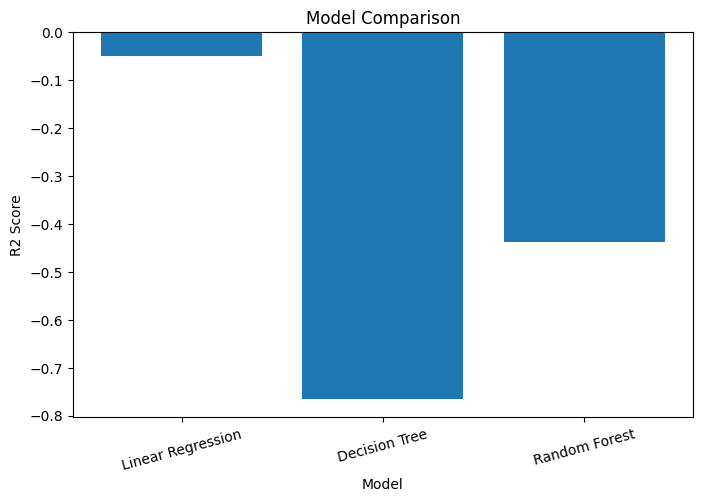

In [59]:
plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["R2 Score"]
)

plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.title("Model Comparison")

plt.xticks(rotation=15)

plt.show()

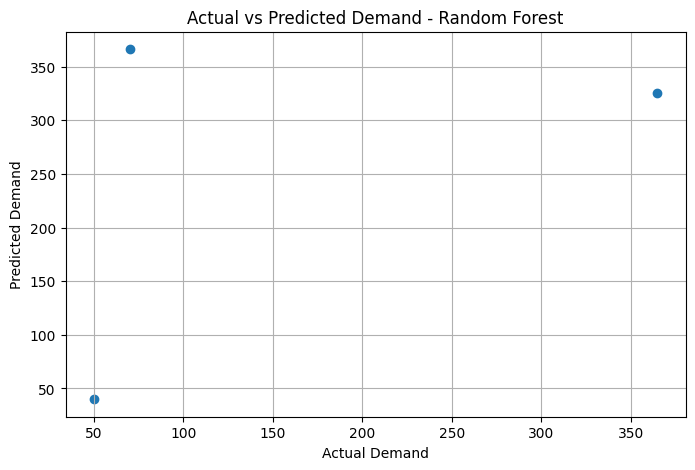

In [60]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    forest_prediction
)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Demand - Random Forest")

plt.grid(True)

plt.show()

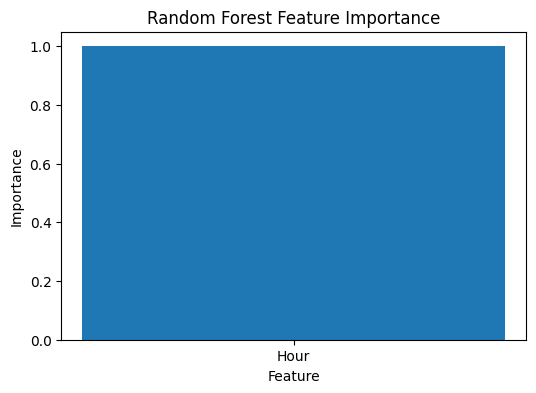

In [61]:
importance = forest_model.feature_importances_

plt.figure(figsize=(6, 4))

plt.bar(
    ["Hour"],
    importance
)

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")

plt.show()

In [62]:
test_hour = pd.DataFrame({
    "hour": [12]
})

prediction = forest_model.predict(test_hour)

print(
    "Predicted service demand at 12:00:",
    round(prediction[0]),
    "requests"
)

Predicted service demand at 12:00: 366 requests


In [63]:
all_hours = pd.DataFrame({
    "hour": range(24)
})

all_hours["predicted_demand"] = forest_model.predict(
    all_hours[["hour"]]
)

all_hours

,hour,predicted_demand
0,0,39.99
1,1,39.99
2,2,35.18
3,3,28.16
4,4,46.54
5,5,58.82
6,6,140.94
7,7,196.97
8,8,293.84
9,9,325.37


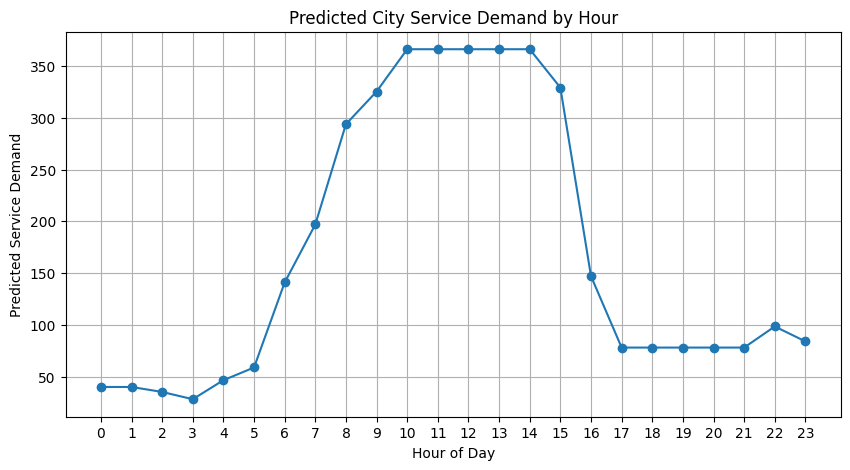

In [64]:
plt.figure(figsize=(10, 5))

plt.plot(
    all_hours["hour"],
    all_hours["predicted_demand"],
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Predicted Service Demand")

plt.title("Predicted City Service Demand by Hour")

plt.xticks(range(24))

plt.grid(True)

plt.show()